# Cell Segmentation – Training Notebook

**Classes:**
- `0` – background  
- `1` – labels 1 & 2 merged (cell type A)  
- `2` – labels 3 & 4 merged (cell type B, rare ~1 %)

**Models tested:**
1. `UNetResNet18` – UNet decoder + ResNet-18 encoder pretrained on ImageNet  
2. `DINOv2Seg`    – frozen DINOv2 ViT-S/14 + lightweight decoder

**Loss:** `CombinedLoss` = 0.5 × Focal(γ=2) + 0.5 × Dice (robust to the heavy class imbalance)

In [ ]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

OWLO_DIR  = r'C:\Users\marti\Desktop\Owlo-test'
UTILS_DIR = os.path.join(OWLO_DIR, 'utils')
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from models           import UNetResNet18, DINOv2Seg
from train_functions  import (
    make_dataloaders, compute_class_weights, CombinedLoss,
    train, validate, predict_slice, load_tif_stack, process_mask,
)

print('PyTorch:', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)

In [ ]:
# ── 1. Configuration ─────────────────────────────────────────────────────────
DATA_DIR   = r'C:\Users\marti\Downloads\2025-11-19_Simu_twocells\2025-11-19_Simu_twocells'
CKPT_DIR   = os.path.join(OWLO_DIR, 'model_weights')   # where to save checkpoints

ALL_K       = list(range(100))   # volume indices 0-99
NUM_CLASSES = 3
SLICE_STRIDE = 2      # take every 2nd slice (~30 slices/volume instead of 61)
VAL_FRAC    = 0.15
BATCH_SIZE  = 8

# Separate epoch counts: UNet is heavier, DINOv2 decoder benefits from more epochs
NUM_EPOCHS_UNET = 10
NUM_EPOCHS_DINO = 10

# Image size fed to the models:
#   UNet   – 128×128  (was 256×256, 4× fewer pixels)
#   DINOv2 – 224×224  (must be divisible by 14)
IMG_SIZE_UNET = (128, 128)
IMG_SIZE_DINO = (224, 224)

In [3]:
# ── 2. Data exploration ───────────────────────────────────────────────────────
from PIL import Image, ImageSequence

k = 20
img_stack  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
mask_stack = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))
mask_proc  = np.stack([process_mask(m) for m in mask_stack])

print(f'Image stack : {img_stack.shape}  dtype={img_stack.dtype}')
print(f'Mask (raw)  : {mask_stack.shape}  unique={np.unique(mask_stack)}')
print(f'Mask (proc) : unique={np.unique(mask_proc)}')

# Count class distribution across ALL volumes (sample 10 volumes)
counts_all = np.zeros(NUM_CLASSES, dtype=np.int64)
for ki in ALL_K[:10]:
    ms = load_tif_stack(os.path.join(DATA_DIR, f'mask_{ki}.tif'))
    for fr in ms:
        pr = process_mask(fr)
        for c in range(NUM_CLASSES):
            counts_all[c] += (pr == c).sum()
total = counts_all.sum()
print('\nClass distribution (10 volumes):')
for c in range(NUM_CLASSES):
    print(f'  class {c}: {counts_all[c]:,}  ({100*counts_all[c]/total:.1f} %)')

Image stack : (61, 256, 255)  dtype=float32
Mask (raw)  : (61, 256, 255)  unique=[  0  51 102 153 204 255]
Mask (proc) : unique=[0 1 2]

Class distribution (10 volumes):
  class 0: 31,056,320  (78.0 %)
  class 1: 8,420,227  (21.1 %)
  class 2: 344,253  (0.9 %)


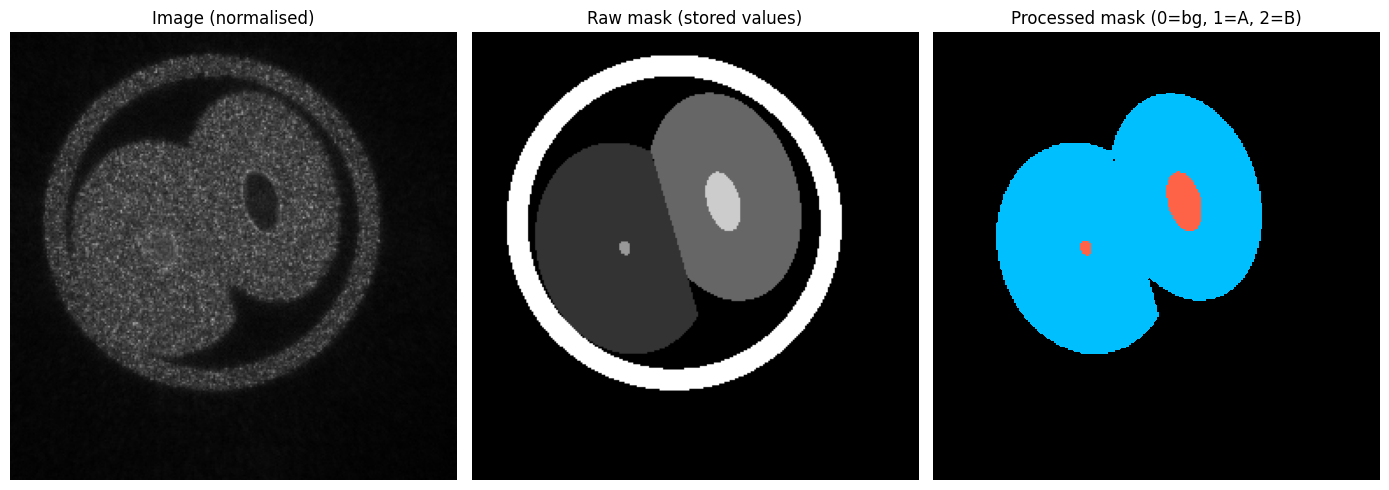

In [4]:
# ── 3. Visualise a sample slice ───────────────────────────────────────────────
CMAP = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])

s = 30   # slice index
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_stack[s],      cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image (normalised)')
axes[1].imshow(mask_stack[s],     cmap='gray')
axes[1].set_title('Raw mask (stored values)')
axes[2].imshow(mask_proc[s],      cmap=CMAP, vmin=0, vmax=2)
axes[2].set_title('Processed mask (0=bg, 1=A, 2=B)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

---
## Model 1 – UNet with ResNet-18 backbone

In [5]:
# ── 4a. DataLoaders (128×128) ────────────────────────────────────────────────
print('Building dataloaders for UNet ...')
train_loader_u, val_loader_u = make_dataloaders(
    DATA_DIR, ALL_K,
    val_frac=VAL_FRAC,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE_UNET,
    stride=SLICE_STRIDE,
)


Building dataloaders for UNet ...
CellDataset: 85 volumes -> 2635 slices
CellDataset: 15 volumes -> 465 slices
  train slices: 2635  |  val slices: 465


In [6]:
# ── 4b. Class weights & loss ──────────────────────────────────────────────────
print('Computing class weights …')
weights_u = compute_class_weights(DATA_DIR, ALL_K, num_classes=NUM_CLASSES)
criterion_u = CombinedLoss(
    num_classes=NUM_CLASSES,
    focal_gamma=2.0,
    class_weights=weights_u.to(DEVICE),
)

Computing class weights …
Class counts (subset): [31056320  8420227   344253]
Class weights: [ 1.     3.688 90.214]


In [7]:
# ── 4c. Model, optimiser, scheduler ──────────────────────────────────────────
model_u = UNetResNet18(num_classes=NUM_CLASSES, in_channels=1, pretrained=True).to(DEVICE)

n_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'UNetResNet18 trainable parameters: {n_params:,}')

# Lower LR (1e-4) + cosine annealing to avoid the oscillating val loss
# seen with 3e-4 + ReduceLROnPlateau
optimizer_u = torch.optim.AdamW(model_u.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler_u = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_u, T_max=NUM_EPOCHS_UNET, eta_min=1e-6
)


UNetResNet18 trainable parameters: 14,407,331


Epoch   1/10 [train]:   0%|          | 0/330 [00:00<?, ?batch/s]c:\Users\marti\Desktop\RAG-project\.venv\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch   1/10  train=0.4228  val=0.3394  mIoU=0.8180  [c0:0.980  c1:0.922  c2:0.714]
  ✓ saved best checkpoint  (mIoU=0.8180)


Epoch   2/10  train=0.2700  val=0.2364  mIoU=0.7939  [c0:0.984  c1:0.927  c2:0.661]


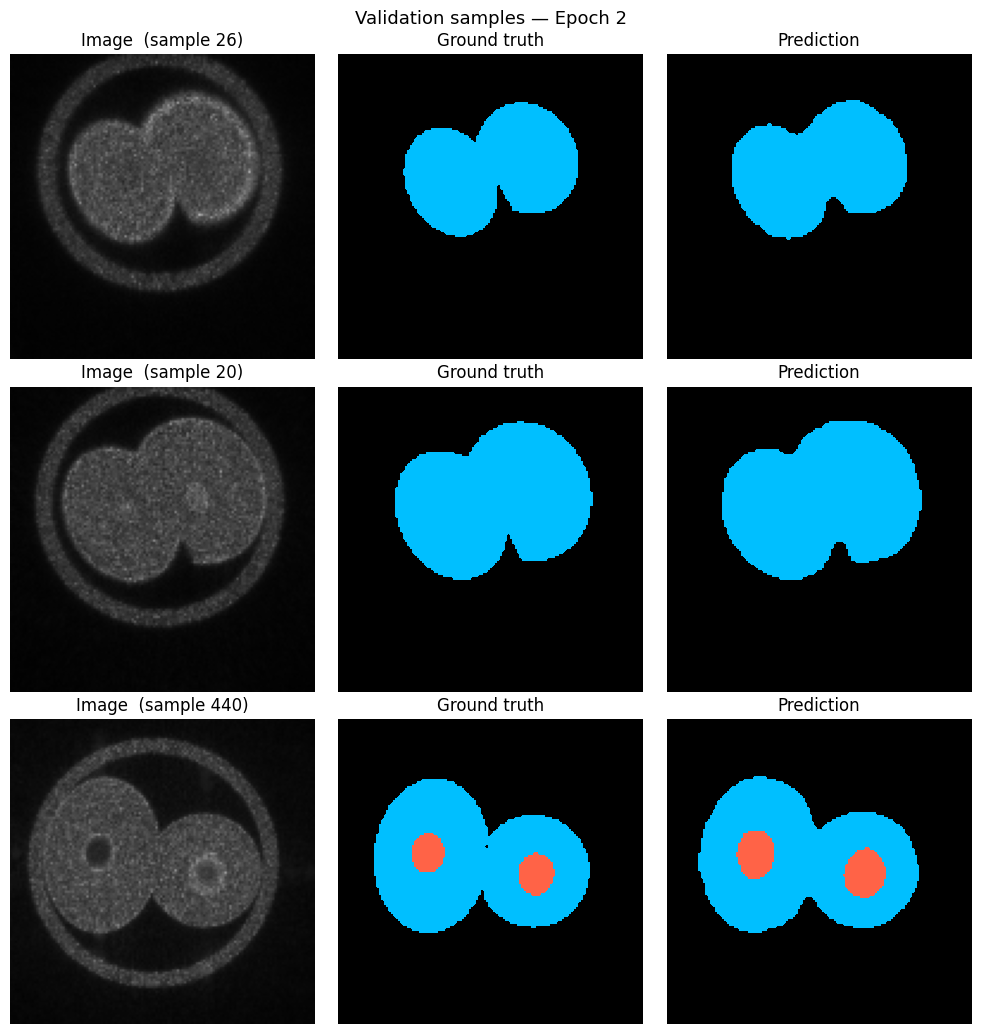

Epoch   3/10  train=0.1722  val=0.1998  mIoU=0.8486  [c0:0.985  c1:0.938  c2:0.759]
  ✓ saved best checkpoint  (mIoU=0.8486)


Epoch   4/10  train=0.1240  val=0.1767  mIoU=0.8219  [c0:0.983  c1:0.928  c2:0.715]


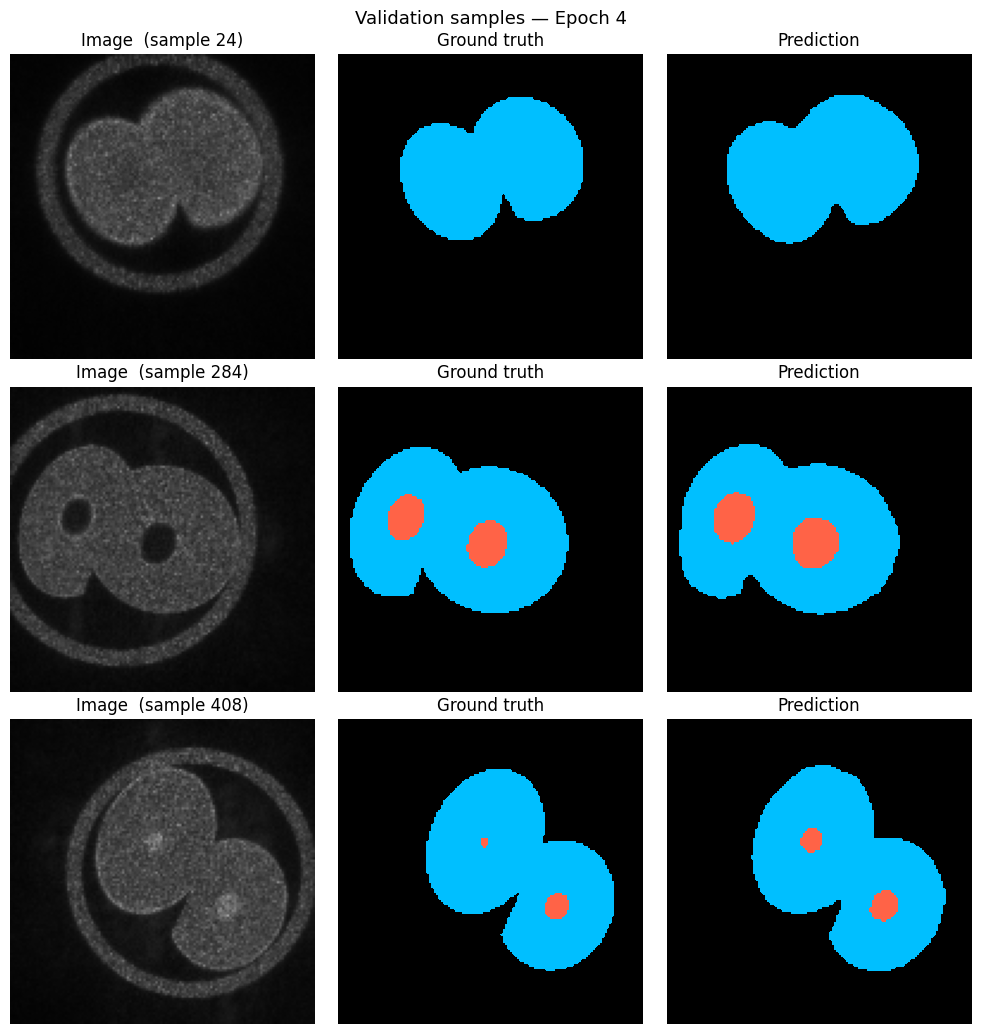

Epoch   5/10  train=0.0983  val=0.1616  mIoU=0.8819  [c0:0.988  c1:0.952  c2:0.812]
  ✓ saved best checkpoint  (mIoU=0.8819)


Epoch   6/10  train=0.0954  val=0.1637  mIoU=0.8682  [c0:0.987  c1:0.947  c2:0.789]


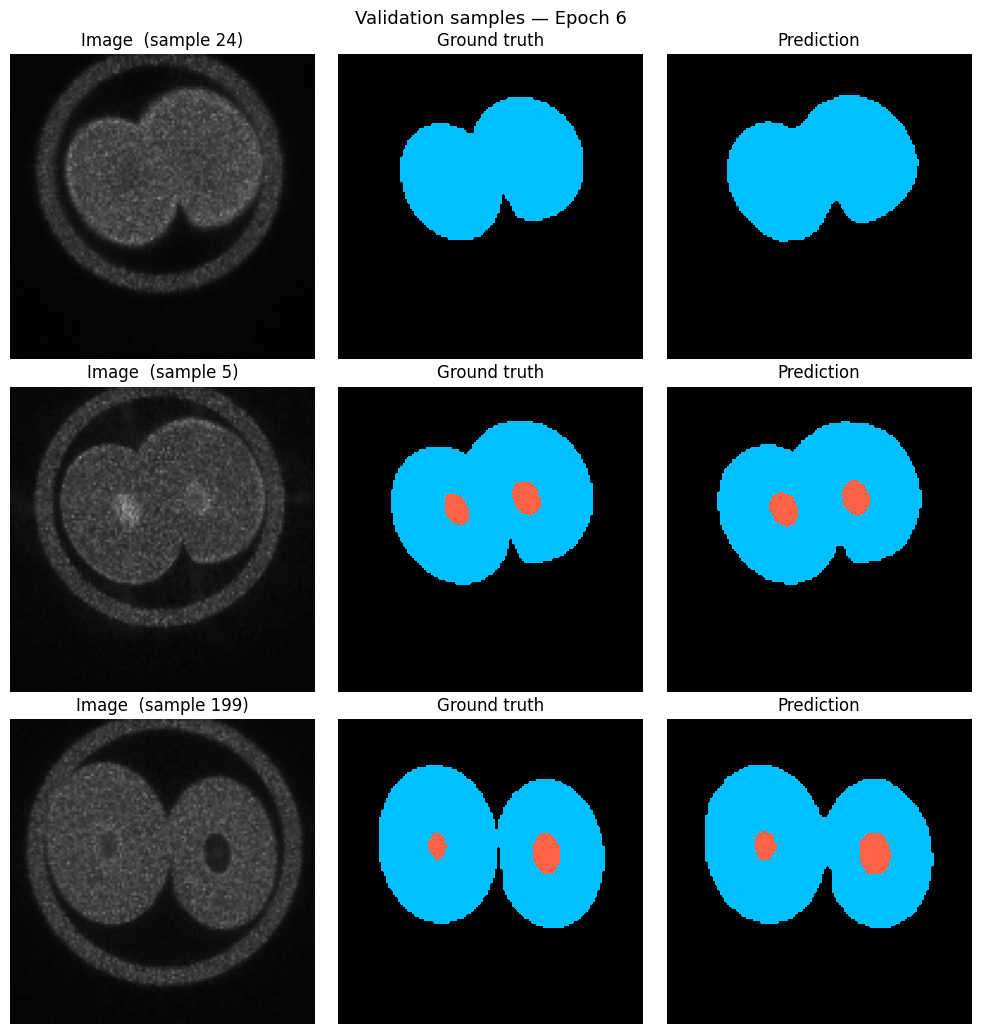

Epoch   7/10  train=0.0782  val=0.1504  mIoU=0.8765  [c0:0.989  c1:0.953  c2:0.800]


Epoch   8/10  train=0.0724  val=0.1466  mIoU=0.8801  [c0:0.989  c1:0.954  c2:0.806]


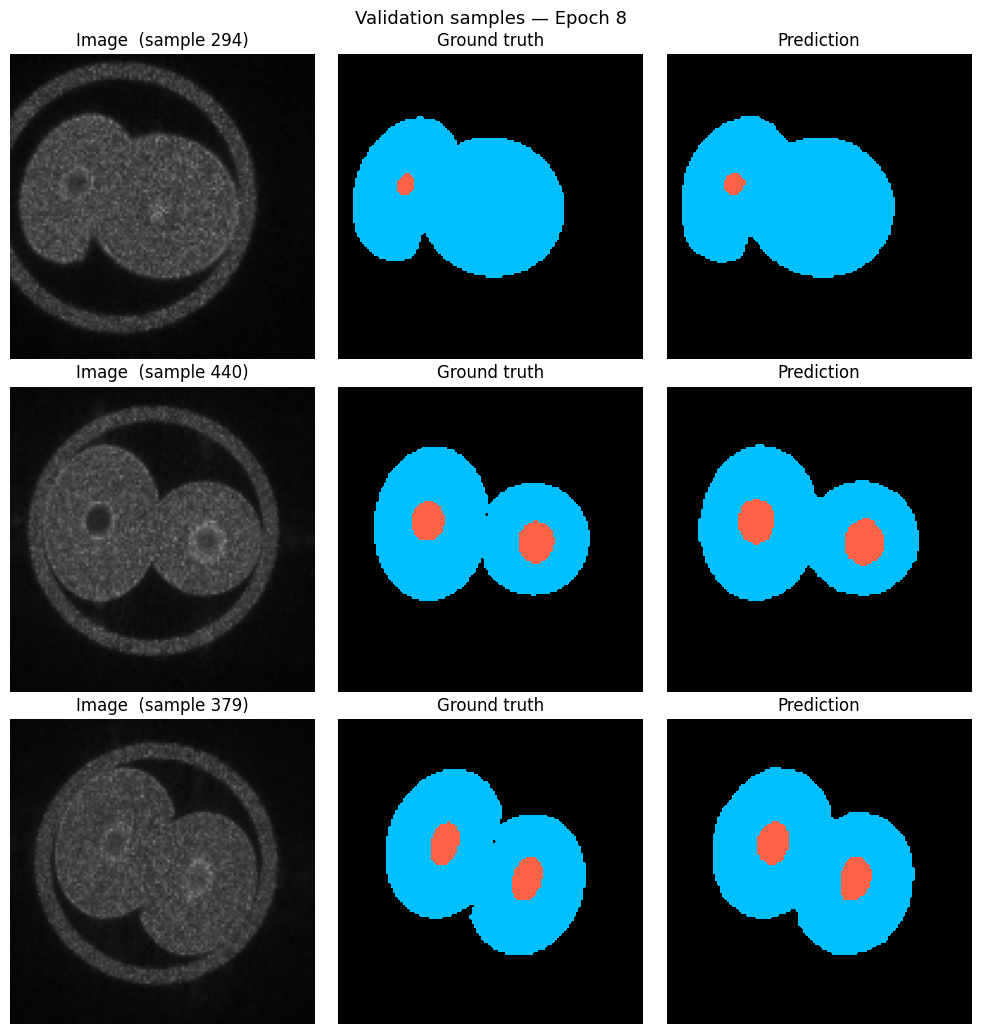

Epoch   9/10  train=0.0690  val=0.1535  mIoU=0.8773  [c0:0.989  c1:0.953  c2:0.802]


Epoch  10/10  train=0.0642  val=0.1504  mIoU=0.8853  [c0:0.989  c1:0.956  c2:0.815]
  ✓ saved best checkpoint  (mIoU=0.8853)


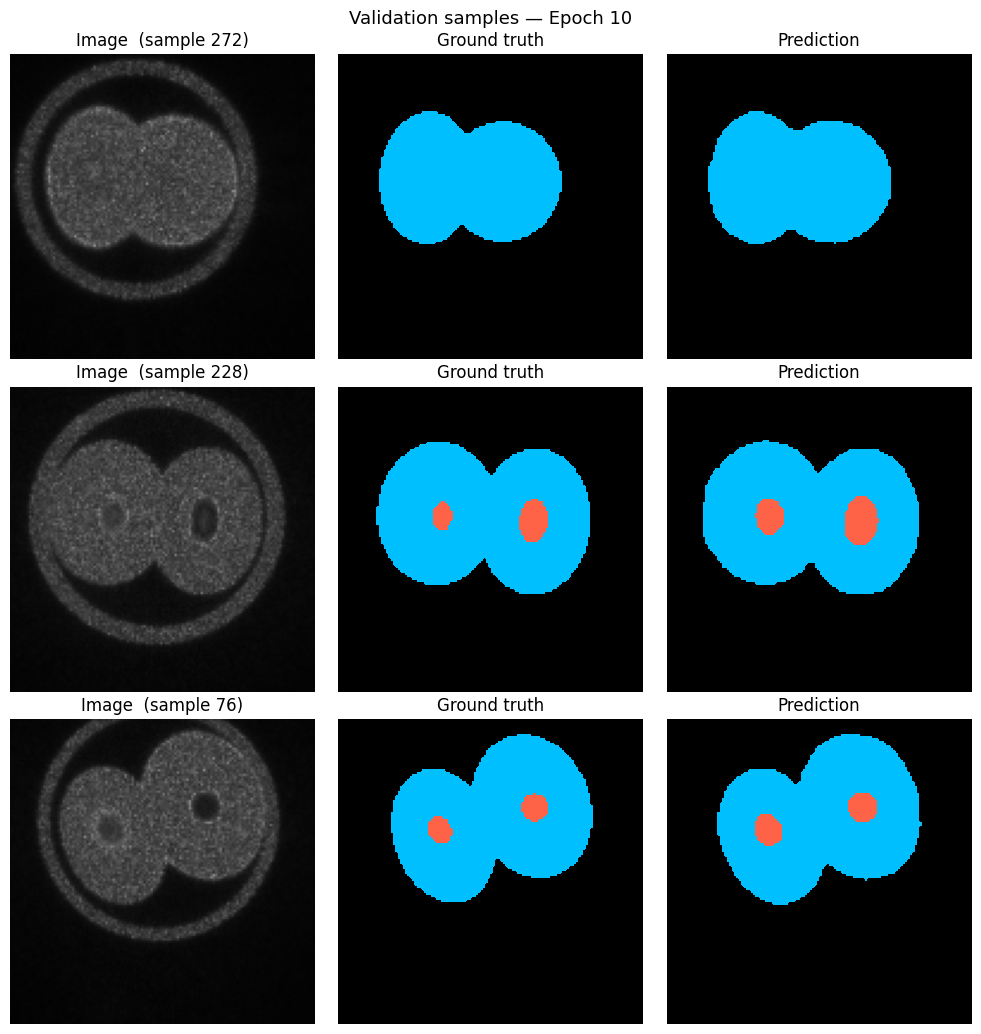

In [8]:
# ── 4d. Train ─────────────────────────────────────────────────────────────────
CKPT_UNET = os.path.join(CKPT_DIR, 'best_unet_resnet18.pth')

history_u = train(
    model_u, train_loader_u, val_loader_u,
    optimizer_u, scheduler_u, criterion_u,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_UNET,
    save_path=CKPT_UNET,
    num_classes=NUM_CLASSES,
)


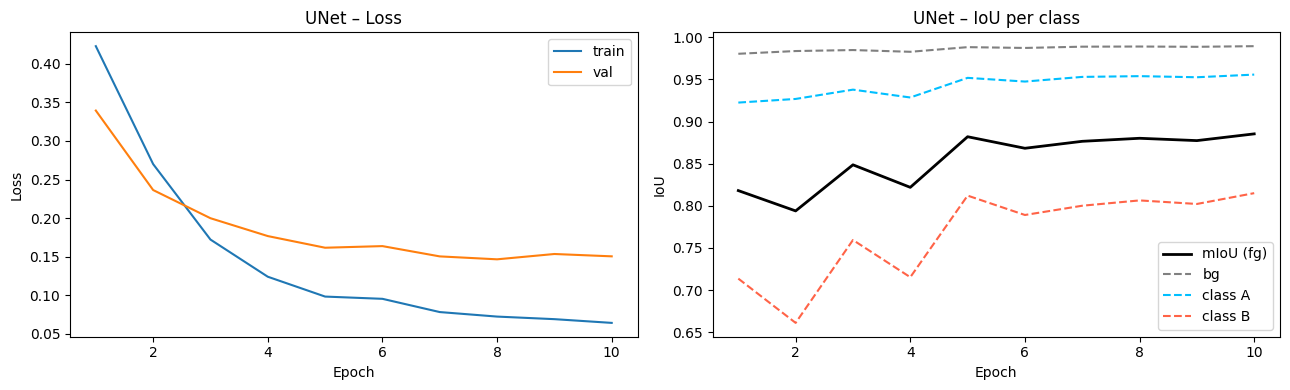

In [9]:
# ── 4e. Learning curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history_u['train_loss']) + 1)

axes[0].plot(epochs, history_u['train_loss'], label='train')
axes[0].plot(epochs, history_u['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('UNet – Loss')

iou_c = np.array(history_u['iou_per_class'])
axes[1].plot(epochs, history_u['mean_iou'], 'k-', lw=2, label='mIoU (fg)')
for c, col, lbl in zip(range(NUM_CLASSES), ['grey','deepskyblue','tomato'],
                        ['bg','class A','class B']):
    axes[1].plot(epochs, iou_c[:, c], '--', color=col, label=lbl)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].legend()
axes[1].set_title('UNet – IoU per class')

plt.tight_layout()
plt.show()

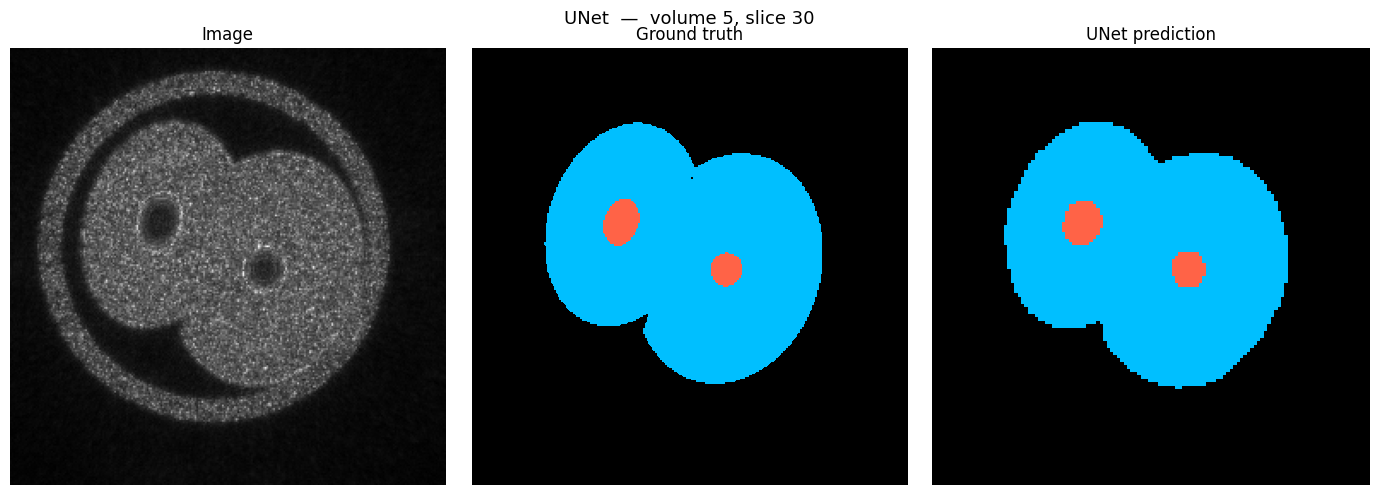

In [10]:
# ── 4f. Visual prediction ─────────────────────────────────────────────────────
# Load best weights
CKPT_UNET = os.path.join(CKPT_DIR, 'best_unet_resnet18.pth')
model_u = UNetResNet18(num_classes=NUM_CLASSES, in_channels=1, pretrained=True).to(DEVICE)
model_u.load_state_dict(torch.load(CKPT_UNET, map_location=DEVICE))

k_vis, s_vis = 5, 30
img_vis  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_vis}.tif'))[s_vis].astype(np.float32) / 255.0
mask_vis = process_mask(load_tif_stack(os.path.join(DATA_DIR, f'mask_{k_vis}.tif'))[s_vis])

pred_u   = predict_slice(model_u, img_vis, DEVICE, img_size=IMG_SIZE_UNET)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_vis,   cmap='gray');       axes[0].set_title('Image')
axes[1].imshow(mask_vis,  cmap=CMAP, vmin=0, vmax=2); axes[1].set_title('Ground truth')
axes[2].imshow(pred_u,    cmap=CMAP, vmin=0, vmax=2); axes[2].set_title('UNet prediction')
for ax in axes: ax.axis('off')
plt.suptitle(f'UNet  —  volume {k_vis}, slice {s_vis}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Model 2 – DINOv2 ViT-S/14 (frozen) + decoder

> **Note:** `torch.hub.load` will download ~330 MB on the first run.  
> The backbone is frozen; only the decoder head is trained.

In [ ]:
# ── 5a. DataLoaders (224×224) ─────────────────────────────────────────────────
print('Building dataloaders for DINOv2 ...')
train_loader_d, val_loader_d = make_dataloaders(
    DATA_DIR, ALL_K,
    val_frac=VAL_FRAC,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE_DINO,
    stride=SLICE_STRIDE,
)


Building dataloaders for DINOv2 ...
CellDataset: 85 volumes -> 2635 slices
CellDataset: 15 volumes -> 465 slices
  train slices: 2635  |  val slices: 465


In [ ]:
# ── 5b. Class weights & loss ──────────────────────────────────────────────────
weights_d   = compute_class_weights(DATA_DIR, ALL_K, num_classes=NUM_CLASSES)
criterion_d = CombinedLoss(
    num_classes=NUM_CLASSES,
    focal_gamma=2.0,
    class_weights=weights_d.to(DEVICE),
)

Class counts (subset): [31056320  8420227   344253]
Class weights: [ 1.     3.688 90.214]


In [ ]:
# ── 5c. Model, optimiser, scheduler ──────────────────────────────────────────
model_d = DINOv2Seg(
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE_DINO[0],
    freeze_backbone=True,
).to(DEVICE)

n_params = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
print(f'DINOv2Seg – trainable parameters: {n_params:,}  (backbone is frozen)')

# Only optimise the decoder; 5e-4 with cosine annealing for smooth convergence
optimizer_d = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_d.parameters()),
    lr=5e-4, weight_decay=1e-4
)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_d, T_max=NUM_EPOCHS_DINO, eta_min=1e-6
)


In [ ]:
# ── 5d. Train ─────────────────────────────────────────────────────────────────
CKPT_DINO = os.path.join(CKPT_DIR, 'best_dinov2_seg.pth')

history_d = train(
    model_d, train_loader_d, val_loader_d,
    optimizer_d, scheduler_d, criterion_d,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_DINO,
    save_path=CKPT_DINO,
    num_classes=NUM_CLASSES,
)


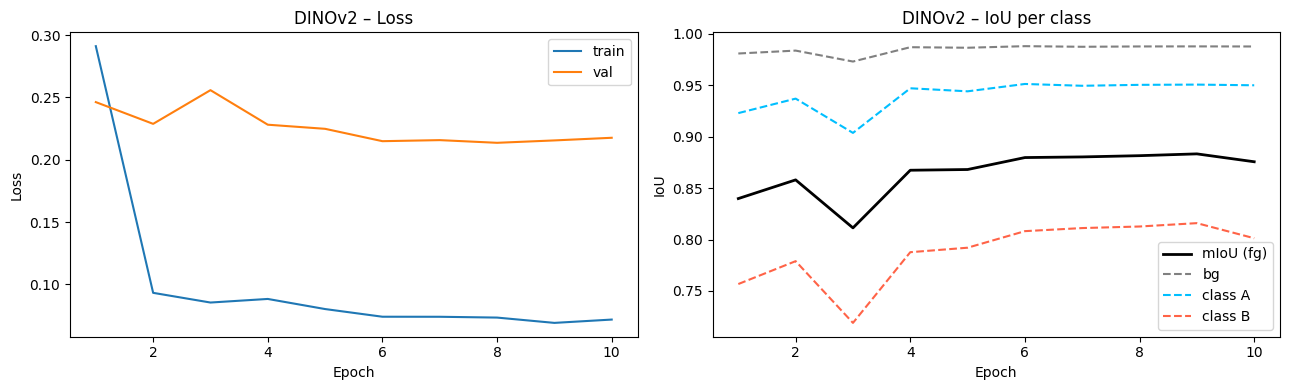

In [ ]:
# ── 5e. Learning curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history_d['train_loss']) + 1)

axes[0].plot(epochs, history_d['train_loss'], label='train')
axes[0].plot(epochs, history_d['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('DINOv2 – Loss')

iou_c = np.array(history_d['iou_per_class'])
axes[1].plot(epochs, history_d['mean_iou'], 'k-', lw=2, label='mIoU (fg)')
for c, col, lbl in zip(range(NUM_CLASSES), ['grey','deepskyblue','tomato'],
                        ['bg','class A','class B']):
    axes[1].plot(epochs, iou_c[:, c], '--', color=col, label=lbl)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].legend()
axes[1].set_title('DINOv2 – IoU per class')

plt.tight_layout()
plt.show()

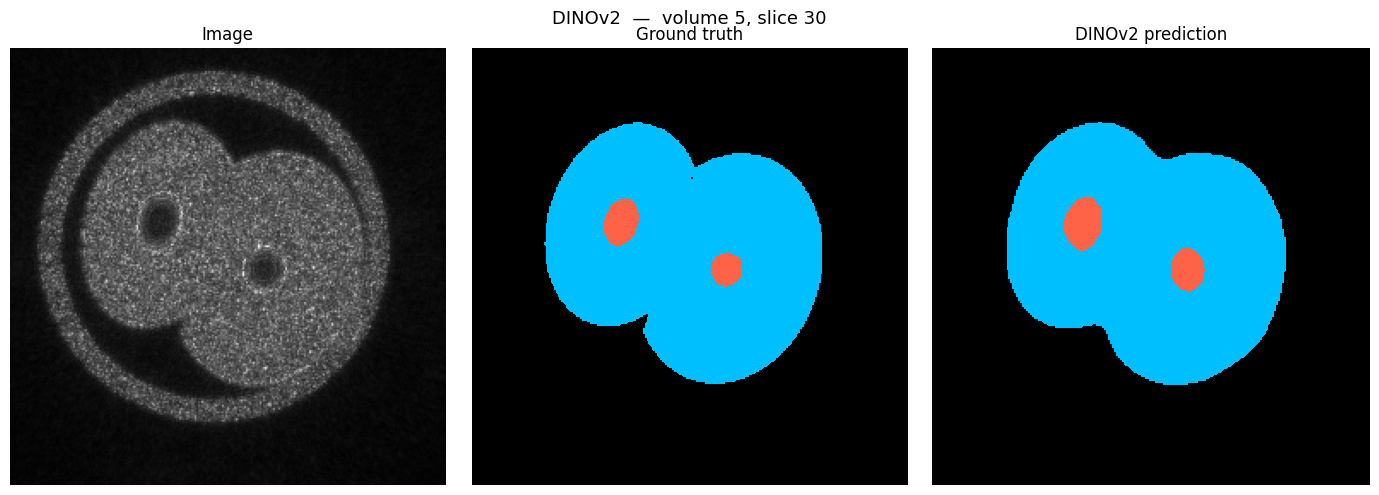

In [ ]:
# ── 5f. Visual prediction ─────────────────────────────────────────────────────
model_d.load_state_dict(torch.load(CKPT_DINO, map_location=DEVICE))

k_vis, s_vis = 5, 30
img_vis  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_vis}.tif'))[s_vis].astype(np.float32) / 255.0
mask_vis = process_mask(load_tif_stack(os.path.join(DATA_DIR, f'mask_{k_vis}.tif'))[s_vis])

pred_d = predict_slice(model_d, img_vis, DEVICE, img_size=IMG_SIZE_DINO)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_vis,   cmap='gray');       axes[0].set_title('Image')
axes[1].imshow(mask_vis,  cmap=CMAP, vmin=0, vmax=2); axes[1].set_title('Ground truth')
axes[2].imshow(pred_d,    cmap=CMAP, vmin=0, vmax=2); axes[2].set_title('DINOv2 prediction')
for ax in axes: ax.axis('off')
plt.suptitle(f'DINOv2  —  volume {k_vis}, slice {s_vis}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Model comparison

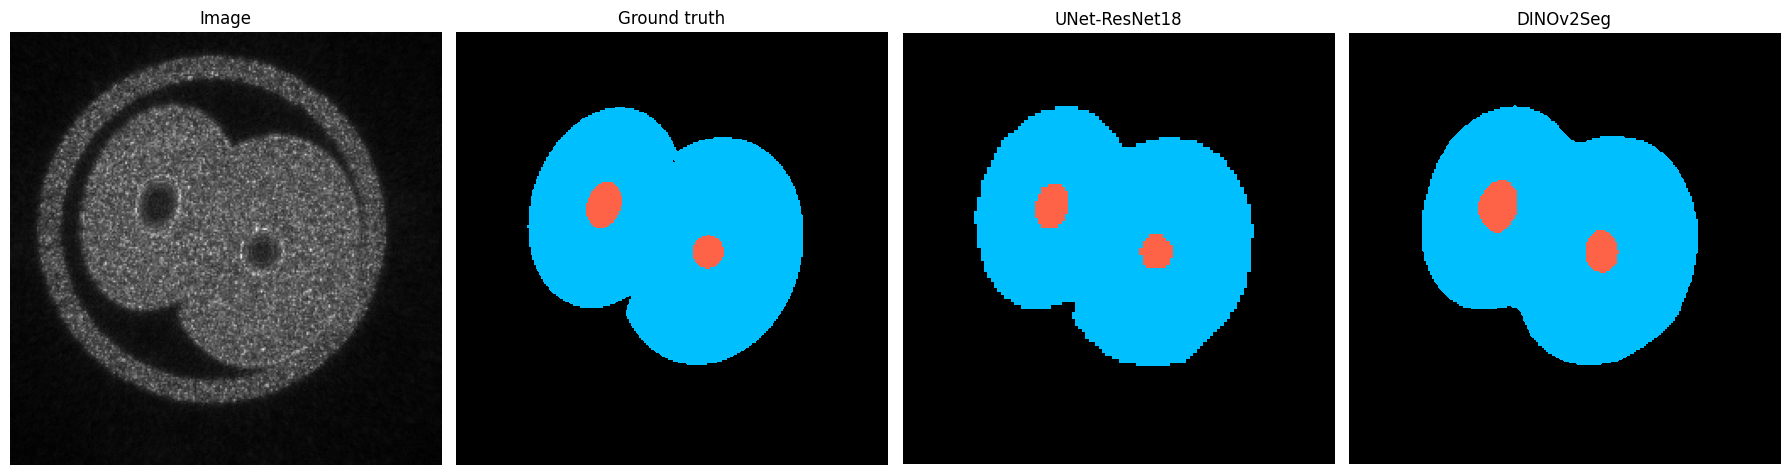

NameError: name 'history_u' is not defined

In [20]:
# ── 6. Side-by-side comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_vis,  cmap='gray');          axes[0].set_title('Image')
axes[1].imshow(mask_vis, cmap=CMAP, vmin=0, vmax=2); axes[1].set_title('Ground truth')
axes[2].imshow(pred_u,   cmap=CMAP, vmin=0, vmax=2); axes[2].set_title('UNet-ResNet18')
axes[3].imshow(pred_d,   cmap=CMAP, vmin=0, vmax=2); axes[3].set_title('DINOv2Seg')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# Numeric comparison – best val mIoU
print(f'Best val mIoU  UNet   : {max(history_u["mean_iou"]):.4f}')
print(f'Best val mIoU  DINOv2 : {max(history_d["mean_iou"]):.4f}')